In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../data/raw/Online Retail.xlsx")
df.shape

(541909, 8)

In [2]:
# Revenue sütunu oluştur
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Tekrarlayan satırları çıkar
df = df.drop_duplicates()

# Negatif fiyatları çıkar (veri hatası)
df = df[df["UnitPrice"] >= 0]

# "A" ile başlayan adjustment/iptal fatura kayıtlarını çıkar
df = df[~df["InvoiceNo"].astype(str).str.startswith("A")]

# Quantity'si 0 olan (anlamsız) satırları çıkar
df = df[df["Quantity"] != 0]

df.shape

(536638, 9)

In [3]:
# Temizlik sonrası eksik değer kontrolü
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135034
Country             0
Revenue             0
dtype: int64

In [4]:
top_products = (
    df.groupby("StockCode")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

StockCode
22197     56427
84077     53751
85099B    47260
85123A    38811
84879     36122
21212     36016
23084     30597
22492     26437
22616     26299
21977     24719
Name: Quantity, dtype: int64

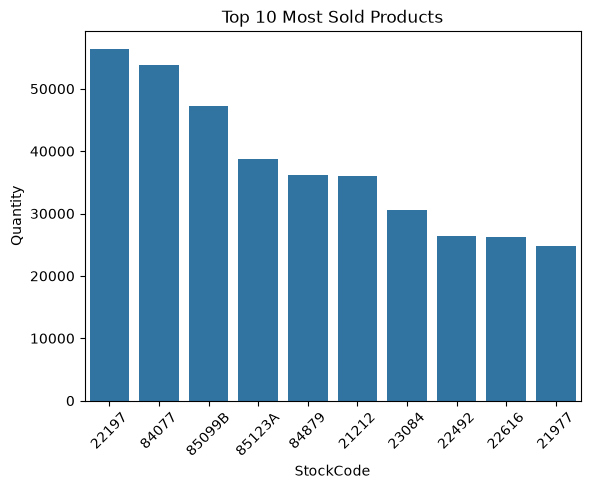

In [5]:
sns.barplot(x=top_products.index.astype(str), y=top_products.values)
plt.xlabel("StockCode")
plt.ylabel("Quantity")
plt.title("Top 10 Most Sold Products")
plt.xticks(rotation=45)
plt.show()

In [12]:
df[df["StockCode"].isin(["POST", "DOT", "M", "C2", "BANK CHARGES", "PADS"])]["StockCode"].value_counts()

StockCode
POST            1256
DOT              710
M                566
C2               144
BANK CHARGES      37
PADS               4
Name: count, dtype: int64

In [13]:
post_invoices = df[df["StockCode"] == "POST"]["InvoiceNo"].unique()

# POST içeren faturalarda kaç farklı StockCode var - ortalama
df[df["InvoiceNo"].isin(post_invoices)].groupby("InvoiceNo")["StockCode"].nunique().describe()

count    1254.000000
mean       17.378788
std        16.300673
min         1.000000
25%         5.000000
50%        14.000000
75%        24.000000
max       149.000000
Name: StockCode, dtype: float64

In [10]:
special_codes = ["POST", "DOT", "M", "BANK CHARGES", "PADS", "C2"]

top_revenue = (
    df[~df["StockCode"].isin(special_codes)]
    .groupby("StockCode")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue_products = top_revenue
top_revenue_products

StockCode
22423     164459.49
47566      98243.88
85123A     97838.45
85099B     92175.79
23084      66661.63
22086      63715.24
84879      58792.42
79321      53746.66
22502      51023.52
22197      50967.92
Name: Revenue, dtype: float64

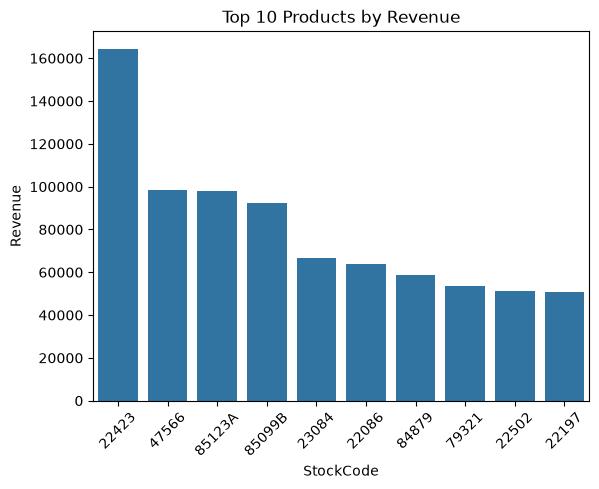

In [11]:
sns.barplot(x=top_revenue_products.index.astype(str), y=top_revenue_products.values)
plt.xlabel("StockCode")
plt.ylabel("Revenue")
plt.title("Top 10 Products by Revenue")
plt.xticks(rotation=45)
plt.show()

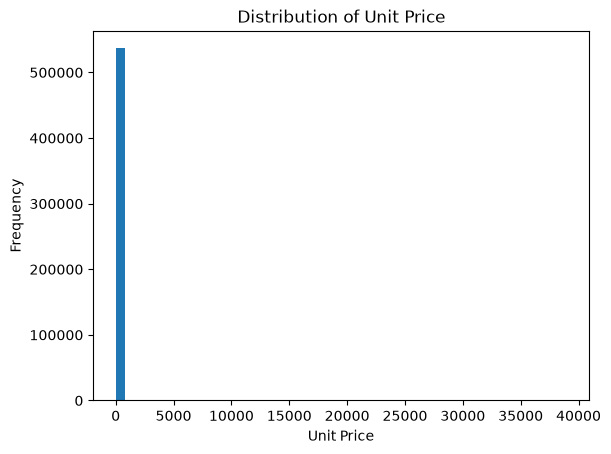

In [8]:
# Genel dağılım (aşırı uç değerler dahil)
plt.hist(df["UnitPrice"], bins=50)
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.title("Distribution of Unit Price")
plt.show()

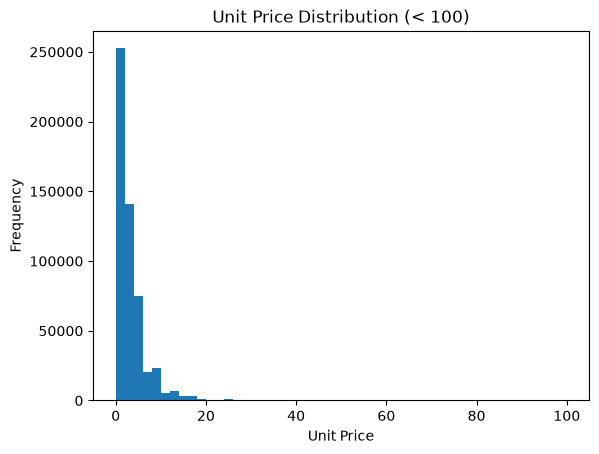

In [9]:
# 100'ün altındaki fiyatlara odaklanarak daha okunaklı dağılım
plt.hist(df[df["UnitPrice"] < 100]["UnitPrice"], bins=50)
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.title("Unit Price Distribution (< 100)")
plt.show()